# Full Method 1 Notebook (Using `main` module)

Refactored to import from the `main` directory.

In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import copy
from pathlib import Path

# Import from main
from main import (
    get_device, set_seed,
    load_participant, get_split_series,
    preprocess_eeg, preprocess_eeg_from_config,
    preprocess_emg, preprocess_emg_from_config, EMGNormalizer,
    preprocess_kinematics, preprocess_kinematics_from_config, KinNormalizer,
    extract_kt, extract_kt_raw,
    WAYEEGDataset,
    KGGTModel, build_kg_gt_from_config, CNN1dAligner,
    build_transformer_only_from_config,
    CombinedEMGLoss, build_loss_from_config,
    train_model, TrainConfig, TrainResult,
    collect_predictions, compute_metrics, EvalMetrics,
    prepare_batch_factory, save_checkpoint, load_checkpoint,
    print_gpu_info,
    compute_muscle_edge_prior,   # for edge-prior computation (follow-up step)
)

ROOT = Path(".")

In [2]:
set_seed(42)
device = get_device()
print(f"Device: {device}")


Device: cuda


In [35]:
CONFIG = {
    "outputs":{
        "figures_dir": "docs/figure/method1",
    },
    "data": {
        "participant": "P1",       
        "data_root": "data/way-eeg/raw",
        "cache_dir": "data/cache_main",
        # window_size=4000 @ 500 Hz = 8 s window; stride=250 = 0.5 s step
        # chunked transformer: 4000 / chunk_size=500 = 8 chunks of 500 → O(500²) not O(4000²)
        "window_size": 500,
        "stride": 100,
        "fs_eeg": 500,                   # Hz
        "fs_emg": 4000,                  # Hz (raw); downsampled to fs_eeg after preprocess
        "fs_kin": 500,                   # Hz
        "n_eeg_channels": 32,
        "n_emg_channels": 5,
        "n_kin_raw": 36,                 # raw kin cols in hs.kin.sig
        "n_kin_features": 13             # k_t dimension after extraction
    },
    "preprocessing": {
        "eeg": {
            "bp_low": 0.5,                  # Hz, bandpass lower bound
            "bp_high": 40.0,                # Hz, bandpass upper bound
            "artifact_method": "ica_auto",  # "asr" | "ica_auto" | "ica_manual"
            "filter_order": 4,
            "notch_freq": 50.0,             # Hz, power-line
            "asr_window_ms": 500,           # ms, ASR sliding window
            "asr_std_thresh": 5.0,          # sigma, ASR rejection threshold
            "delta_low": 0.5,               # Hz, delta-band lower bound
            "delta_high": 40.0,             # Hz, delta-band upper bound
            "use_car": False,
            "use_tkeo": True,
            #"target_channels": ["FC1", "FC2", "C3", "Cz", "C4", "CP1", "CP2", "CP6"]
        },
        "emg": {
            "bp_low": 30.0,              # Hz
            "bp_high": 300.0,            # Hz
            "filter_order": 4,
            "lp_cutoff": 10.0,           # Hz, low-pass for envelope
            "downsample_factor": 8       # 4000 -> 500 Hz
        },
        "kinematics": {
            "include_velocity": False,   # if true, output is (T, 26) = k_t + velocity
            "velocity_method": "sg",     # 'sg' (Savitzky-Golay) | 'bw' (Butterworth diff)
            "sg_window": 11,             # SG window length (samples, must be odd)
            "sg_poly": 3,                # SG polynomial order
            "bw_cutoff": 20.0,           # LP cutoff Hz before diff (used when method='bw')
            "bw_order": 4,               # Butterworth order (used when method='bw')
            "normalize": True            # per-feature z-score over training set
        },
    },
    "model": {
        "type": "transformer_regressor",
        "transformer": {
            "n_layers": 4,
            "n_heads": 8,
            "d_model": 128,
            "d_k": 32,
            "d_v": 32,
            "ffn_dim": 512,
            "dropout": 0.1,
            # chunk_size=500 with window_size=4000 → 8 chunks of 500
            # → O(500²)=250K scores per head (not O(4000²)=16M)
            # MUST divide window_size evenly or a RuntimeWarning fires and
            # full O(T²) attention is used (catastrophically slow).
            "chunk_size": 500
        },
        "gat": {
            "n_layers": 2,
            "node_dim": 64,
            "hidden_dim": 64,
            "heads": 4,
            "dropout": 0.2,
            "use_kinematic_guidance": False,
        },
        "decoder": {
            "out_channels": 5            # predicted EMG channels
        }
    },
    "training": {
        # ── optimizer ─────────────────────────────────────────────────────
        "optimizer":   "adam",   # 'adam' | 'adamw'
        "weight_decay": 1e-2,     # AdamW weight decay (ignored for adam)
        # ── scheduler ─────────────────────────────────────────────────────
        "scheduler":   "reduce",  # 'reduce' | 'cosine'
        # reduce-specific
        "lr_patience": 10,
        "lr_factor":   0.5,
        # cosine-specific
        "cosine_t_max":   None,   # None → use max_epochs
        "cosine_eta_min": 1e-6,
        # ── common ────────────────────────────────────────────────────────
        "loss_lambda":  1.0,      # 1.0 = plain MSE; <1.0 enables Soft-DTW (O(T²), DO NOT use at T=4000)
        "lr":                  5e-3,
        # batch_size=4 with T=4000 keeps VRAM safe on GTX 1660 Ti (6 GB).
        # effective batch = batch_size * gradient_accumulation_steps = 4 * 8 = 32
        # Tune batch_size up (e.g. 8) if VRAM is available; reduce grad_accum_steps proportionally.
        "batch_size":          32,
        "gradient_accumulation_steps": 8,
        "early_stop_patience": 15,
        "grad_clip_norm":      1.0,
        "max_epochs":          2,
        # use_amp=True: enables FP16 mixed precision via torch.autocast + GradScaler.
        # GTX 1660 Ti (sm_75 Turing) has FP16 tensor cores → ~1.5-2x speedup.
        # Requires PyTorch >= 2.0. Set False only if you see NaN losses.
        "use_amp":             True,
        "log_memory_every":    50,
        "losocv": True,           # leave-one-subject-out cross-validation
        "checkpoint_every":     1,
        "seed":                42,
    },
    "dataset": {
        # Keep in sync with data.window_size / data.stride above
        "window_size": 500,
        "stride": 100,
    }
}
notebook_cfg = copy.deepcopy(CONFIG)


In [36]:
def make_preprocess_fn(cfg):
    eeg_cfg = cfg["preprocessing"]["eeg"]
    emg_cfg = cfg["preprocessing"]["emg"]
    kin_cfg = cfg["preprocessing"]["kinematics"]
    def preprocess_fn(series):
        series = dict(series)
        series["eeg"] = preprocess_eeg_from_config(
            series["eeg"],
            float(series["fs_eeg"]),
            eeg_cfg,
            channel_names=series.get("eeg_names"),
        )
        series["emg"] = preprocess_emg_from_config(
            series["emg"],
            float(series["fs_emg"]),
            emg_cfg,
        )
        series["kin"] = preprocess_kinematics_from_config(                                           
              series["kin"],                                                                           
              float(series["fs_kin"]),                                                                 
              kin_cfg,                                                                                 
        ) 
        return series

    return preprocess_fn

def build_dataset_split(cfg, participants=None, split="train", root_dir=ROOT):
    data_cfg = cfg["data"]
    if participants is None:
        p_str = data_cfg["participant"]
        p_id = int(p_str.replace("P", "")) if isinstance(p_str, str) else p_str
        participants = [p_id]
        
    return WAYEEGDataset(
        data_dir=root_dir / data_cfg["data_root"],
        participants=participants,
        split=split,
        window_size=cfg["dataset"]["window_size"],
        stride=cfg["dataset"]["stride"],
        preprocess_fn=make_preprocess_fn(cfg),
        cache_dir= root_dir / data_cfg["cache_dir"]
    )

train_ds = build_dataset_split(notebook_cfg, split="train")
val_ds = build_dataset_split(notebook_cfg, split="val")
test_ds = build_dataset_split(notebook_cfg, split="test")

print(f"Train windows: {len(train_ds)}, Val windows: {len(val_ds)}, Test windows: {len(test_ds)}")


Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 3.8s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 13.8s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 16.7s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 6.9s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 4.9s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 14.8s.
Fitting ICA to data using 32 channels (please be patient, thi

In [37]:
def unique_series_arrays(ds):
    seen, eegs, kins, emgs = set(), [], [], []
    for eeg_all, kin_all, emg_all, _ in ds._windows:
        key = id(eeg_all)
        if key in seen:
            continue
        seen.add(key)
        eegs.append(eeg_all)
        kins.append(kin_all)
        emgs.append(emg_all)
    return eegs, kins, emgs

train_eegs, train_kins, train_emgs = unique_series_arrays(train_ds)
kin_all = np.concatenate(train_kins, axis=0)
emg_all = np.concatenate(train_emgs, axis=0)

emg_mean = torch.tensor(emg_all.mean(axis=0), dtype=torch.float32, device=device)
emg_std = torch.tensor(emg_all.std(axis=0), dtype=torch.float32, device=device)
kin_mean = torch.tensor(kin_all.mean(axis=0), dtype=torch.float32, device=device)
kin_std = torch.tensor(kin_all.std(axis=0), dtype=torch.float32, device=device)

emg_std = torch.clamp(emg_std, min=1e-6)
kin_std = torch.clamp(kin_std, min=1e-6)

def local_prepare_batch_factory(emg_mean, emg_std, kin_mean, kin_std, device, drop_kin_indices=None):       
    def prepare_batch(eeg, kin, emg):                                                                
        eeg = eeg.to(device, non_blocking=True)
        kin = kin.to(device, non_blocking=True)
        emg = emg.to(device, non_blocking=True)
        
        kin_norm = (kin - kin_mean) / kin_std
        
        # Drop the chosen indices before passing to the model
        if drop_kin_indices is not None:
            keep_idx = [i for i in range(kin_norm.shape[-1]) if i not in drop_kin_indices]
            kin_norm = kin_norm[..., keep_idx]
            
        emg_norm = (emg - emg_mean) / emg_std
        return {"eeg": eeg, "kin": kin_norm}, emg_norm
    return prepare_batch 

# Pass the index 12 (rho_GL) to drop it
drop_indices = [12]
prepare_batch = local_prepare_batch_factory(emg_mean, emg_std, kin_mean, kin_std, device, drop_kin_indices=drop_indices)
print("Normalisation factors computed.")


Normalisation factors computed.


In [38]:
sample_eeg, sample_kin, sample_emg = train_ds[0]

# Define how many features are dropped
drop_kin_indices = [12]
# Infer dynamically:
dummy_eeg = torch.as_tensor(sample_eeg).unsqueeze(0)
dummy_kin = torch.as_tensor(sample_kin).unsqueeze(0)
dummy_emg = torch.as_tensor(sample_emg).unsqueeze(0)
batch_inputs, _ = prepare_batch(dummy_eeg, dummy_kin, dummy_emg)
true_eeg_dim = batch_inputs["eeg"].shape[-1]
true_kin_dim = batch_inputs["kin"].shape[-1]
true_eeg_dim = sample_eeg.shape[-1]

print("Computing muscle edge prior from training EMG...")
# train_emgs is already extracted in the previous cell!
prior_np = compute_muscle_edge_prior(train_emgs)
edge_prior = torch.from_numpy(prior_np)
print(f"Computed edge prior matrix:\n{prior_np}")

# Build loss
loss_fn = build_loss_from_config(notebook_cfg)

print("Loss function built successfully (Soft-DTW removed!).")


Computing muscle edge prior from training EMG...
Computed edge prior matrix:
[[1.         0.7476082  0.48372698 0.49959463 0.6545633 ]
 [0.7476082  1.         0.5255822  0.5307843  0.6763745 ]
 [0.48372698 0.5255822  1.         0.33063325 0.42928177]
 [0.49959463 0.5307843  0.33063325 1.         0.4692604 ]
 [0.6545633  0.6763745  0.42928177 0.4692604  1.        ]]
Loss function built successfully (Soft-DTW removed!).


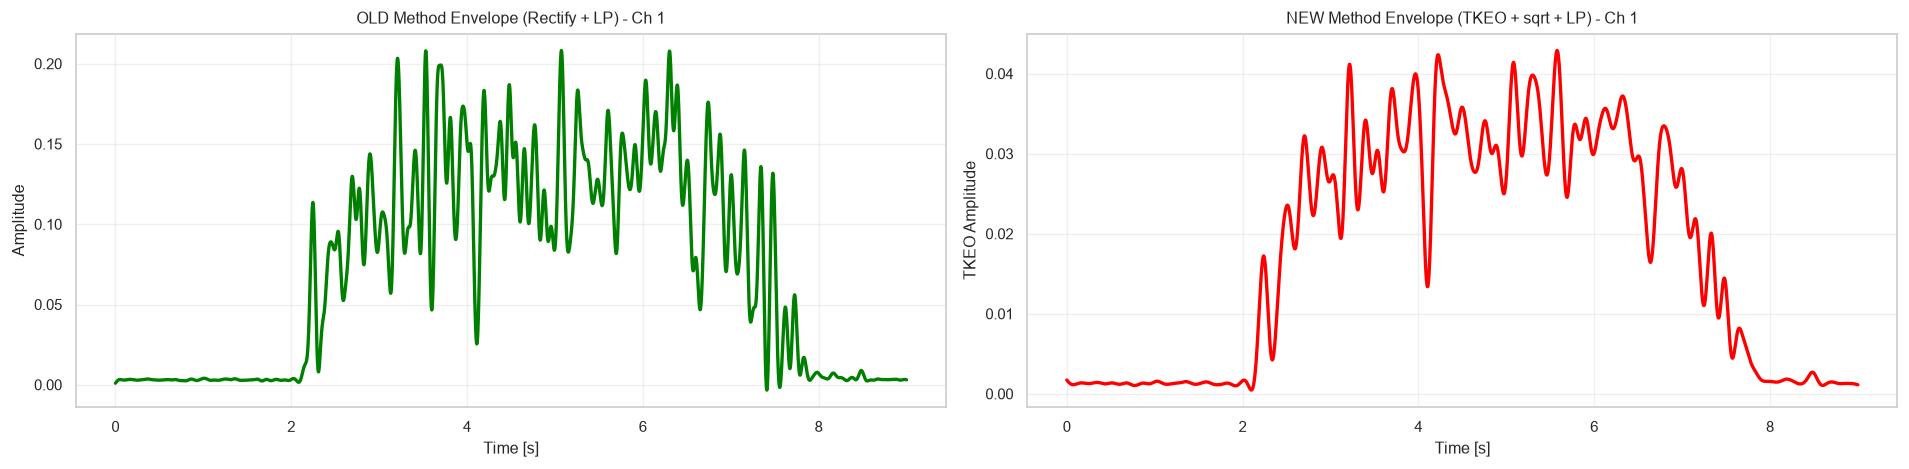

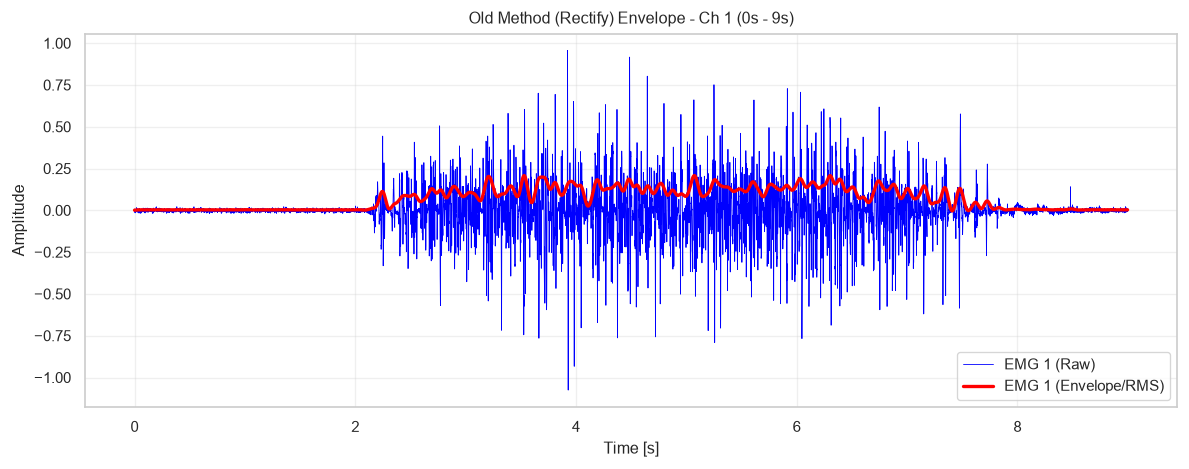

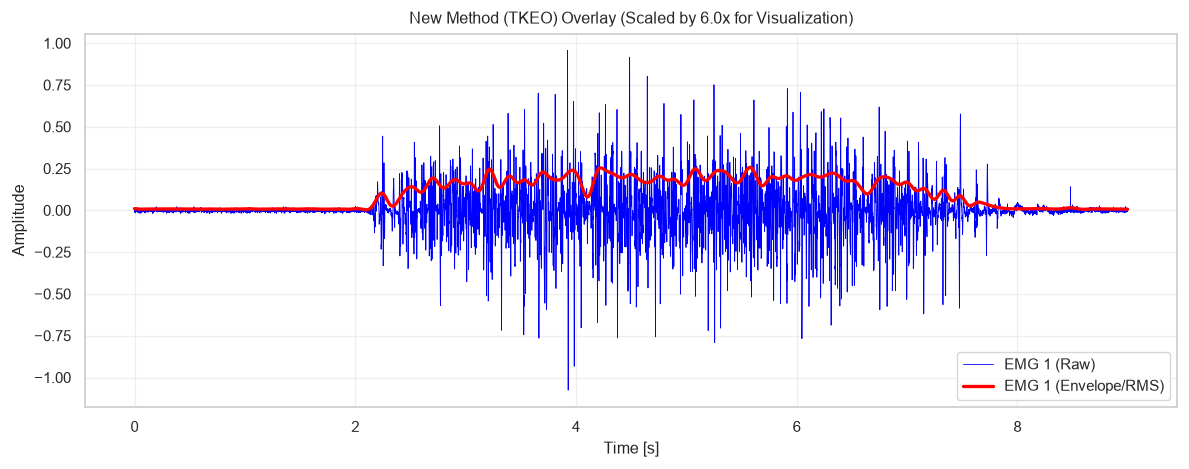

In [39]:
import matplotlib.pyplot as plt
from main.dataloader import load_hs
from main.preprocessing_emg_kin import preprocess_emg_from_config
from main.plots import plot_emg_envelope_overlay

# 1. Load the continuous series dictionary
data_path = "data/way-eeg/raw/P1/HS_P1_S1.mat" # Adjust as needed
hs_data = load_hs(data_path) 
emg_raw = hs_data["emg"]
fs_raw = float(hs_data["fs_emg"])
fs_env = 500.0  # Standard downsampled rate

# 2. Process with the Old Method (Rectify + Lowpass)
cfg_old = {"bp_low": 30.0, "bp_high": 300.0, "lp_cutoff": 10.0, "use_tkeo": False}
emg_old = preprocess_emg_from_config(emg_raw, fs=fs_raw, cfg=cfg_old)

# 3. Process with the New Method (TKEO + Lowpass)
# Change the lp_cutoff from 10.0 to 3.0 (or 5.0) to aggressively smooth the envelope!
cfg_new = {"bp_low": 30.0, "bp_high": 300.0, "lp_cutoff": 6.0, "use_tkeo": True}
emg_tkeo = preprocess_emg_from_config(emg_raw, fs=fs_raw, cfg=cfg_new)

# ==========================================
# 4. Slice a 20-second window
# ==========================================
start_sec = 0
end_sec = 9

# Calculate array indices based on sampling rates
start_idx_raw, end_idx_raw = int(start_sec * fs_raw), int(end_sec * fs_raw)
start_idx_env, end_idx_env = int(start_sec * fs_env), int(end_sec * fs_env)

# Apply slices
emg_raw_slice = emg_raw[start_idx_raw:end_idx_raw]
emg_old_slice = emg_old[start_idx_env:end_idx_env]
emg_tkeo_slice = emg_tkeo[start_idx_env:end_idx_env]


# 5. Plot using the built-in overlay function
channel = 0  # Change this to view different muscles

# Set up a figure with 2 subplots (side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
time_env = np.linspace(start_sec, end_sec, len(emg_tkeo_slice))

# ----------------------------------------------------
# 1. Plot the OLD Method Envelope (Rectification)
# ----------------------------------------------------
ax1.plot(time_env, emg_old_slice[:, channel], color="green", linewidth=2.0)
ax1.set_title(f"OLD Method Envelope (Rectify + LP) - Ch {channel + 1}")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Amplitude")
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------
# 2. Plot the NEW Method Envelope (TKEO)
# ----------------------------------------------------
ax2.plot(time_env, emg_tkeo_slice[:, channel], color="red", linewidth=2.0)
ax2.set_title(f"NEW Method Envelope (TKEO + sqrt + LP) - Ch {channel + 1}")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("TKEO Amplitude")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Overlay for the Old Method (First 20s)
fig1 = plot_emg_envelope_overlay(
    raw_emg=emg_raw_slice, 
    env_emg=emg_old_slice, 
    fs_raw=fs_raw, 
    fs_env=fs_env, 
    channel_idx=channel, 
    title=f"Old Method (Rectify) Envelope - Ch {channel + 1} ({start_sec}s - {end_sec}s)"
)

# Overlay for the New TKEO Method (First 20s)
empirical_scale_factor = 6.0 
emg_tkeo_scaled_for_overlay = emg_tkeo_slice * empirical_scale_factor

fig2 = plot_emg_envelope_overlay(
    raw_emg=emg_raw_slice, 
    env_emg=emg_tkeo_scaled_for_overlay, 
    fs_raw=fs_raw, 
    fs_env=fs_env, 
    channel_idx=channel, 
    title=f"New Method (TKEO) Overlay (Scaled by {empirical_scale_factor}x for Visualization)"
)
plt.show()

### **Understanding the Output Above: GAT & Edge Prior**

**1. What is the Edge Prior Matrix?**
The matrix printed above is the **empirical Pearson correlation matrix** of the 5 muscle EMG envelopes across the entire training dataset. 
- A value like `0.735` between Muscle 1 and Muscle 2 means they frequently co-activate in the physical data.
- By initializing the learnable `edge_bias` parameter with this matrix (via a log transform), we give the model a physiological "shortcut". Instead of forcing the model to learn the biomechanical structure of the hand blindly, it starts with the knowledge of which muscles naturally fire together.

**2. How does the Graph Attention Network (GAT) use this?**
In our architecture, the 5 muscle groups are treated as nodes in a graph. For every single time step, they communicate to negotiate the final predicted EMG values:
- **Feature Matching**: Each muscle node generates a Query ($Q$) and Key ($K$). Raw similarity is computed as $Q \cdot K^T$.
- **Edge Bias Addition**: The static structural bias is added: `Scores = (Q @ K^T) + edge_bias`.
- **Kinematic Guidance (Dynamic Bias)**: If enabled, the kinematic state $k_t$ is passed through a small MLP to generate a dynamic bias, which is also added. This allows the graph structure to morph depending on the hand's physical state.
- **Softmax & Aggregation**: The final scores are converted to probabilities via Softmax, and used to aggregate the Value ($V$) vectors from other muscles. This ensures physically realistic co-activations in the final regression output.

In [18]:
batch_size = notebook_cfg["training"]["batch_size"]

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,
                          pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)

# ============================================================================
# Stage 1: Pre-train Transformer-Only Model
# ============================================================================
print("--- STAGE 1: Transformer Pre-training ---")
from main import build_transformer_only_from_config
stage1_model = build_transformer_only_from_config(
    notebook_cfg, 
    input_dim=true_eeg_dim
).to(device)

train_cfg_stage1 = TrainConfig.from_config(
    notebook_cfg["training"], 
    max_epochs=notebook_cfg["training"]["max_epochs"]
)
train_cfg_stage1.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + "_stage1"

result_stage1 = train_model(
    model=stage1_model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=device,
    cfg=train_cfg_stage1,
    resume=False,
)
print("Stage 1 Training finished.")

--- STAGE 1: Transformer Pre-training ---
  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 95.2 MB
  OK  VRAM reserved   : 7912.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active
  Optimizer : ADAM  (weight_decay=0.01)
  Scheduler : REDUCE  (patience=10, factor=0.5)

Starting fresh training run  (checkpoint_dir=outputs/checkpoints_main_stage1)



  Ep    1 [train]:   0%|          | 0/116 [00:00<?, ?batch/s]

  Ep    1 [val  ]:   0%|          | 0/31 [00:00<?, ?batch/s]

  Ep    2 [train]:   0%|          | 0/116 [00:00<?, ?batch/s]

  Ep    2 [val  ]:   0%|          | 0/31 [00:00<?, ?batch/s]


Training done.  Best val loss = 0.9113
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints_main_stage1
Stage 1 Training finished.


In [19]:
# ============================================================================
# Stage 2: Train Full KG-GT Model with Frozen Transformer
# ============================================================================
print("\n--- STAGE 2: GAT Training (Frozen Transformer) ---")

model = build_kg_gt_from_config(
    notebook_cfg, 
    input_dim=true_eeg_dim,
    kin_dim=true_kin_dim,
    edge_prior=edge_prior
).to(device)

# Load Transformer & NodeProjection weights from Stage 1
best_stage1_state = result_stage1.best_state
if best_stage1_state is not None:
    filtered_state = {k: v for k, v in best_stage1_state.items() if k.startswith("encoder.") or k.startswith("node_projection.")}
    model.load_state_dict(filtered_state, strict=False)
    print("Loaded pretrained Transformer weights into KGGTModel.")

# Freeze Transformer and NodeProjection
for param in model.encoder.parameters():
    param.requires_grad = False
for param in model.node_projection.parameters():
    param.requires_grad = False

train_cfg_stage2 = TrainConfig.from_config(
    notebook_cfg["training"], 
    max_epochs=notebook_cfg["training"]["max_epochs"]
)
train_cfg_stage2.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + "_stage2"

result_stage2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=device,
    cfg=train_cfg_stage2,
    resume=False,
)
print("Stage 2 Training finished.")



--- STAGE 2: GAT Training (Frozen Transformer) ---
Loaded pretrained Transformer weights into KGGTModel.
  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 110.7 MB
  OK  VRAM reserved   : 7912.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active
  Optimizer : ADAM  (weight_decay=0.01)
  Scheduler : REDUCE  (patience=10, factor=0.5)

Starting fresh training run  (checkpoint_dir=outputs/checkpoints_main_stage2)



  Ep    1 [train]:   0%|          | 0/116 [00:00<?, ?batch/s]

  Ep    1 [val  ]:   0%|          | 0/31 [00:00<?, ?batch/s]

  Ep    2 [train]:   0%|          | 0/116 [00:00<?, ?batch/s]

  Ep    2 [val  ]:   0%|          | 0/31 [00:00<?, ?batch/s]


Training done.  Best val loss = 0.9025
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints_main_stage2
Stage 2 Training finished.


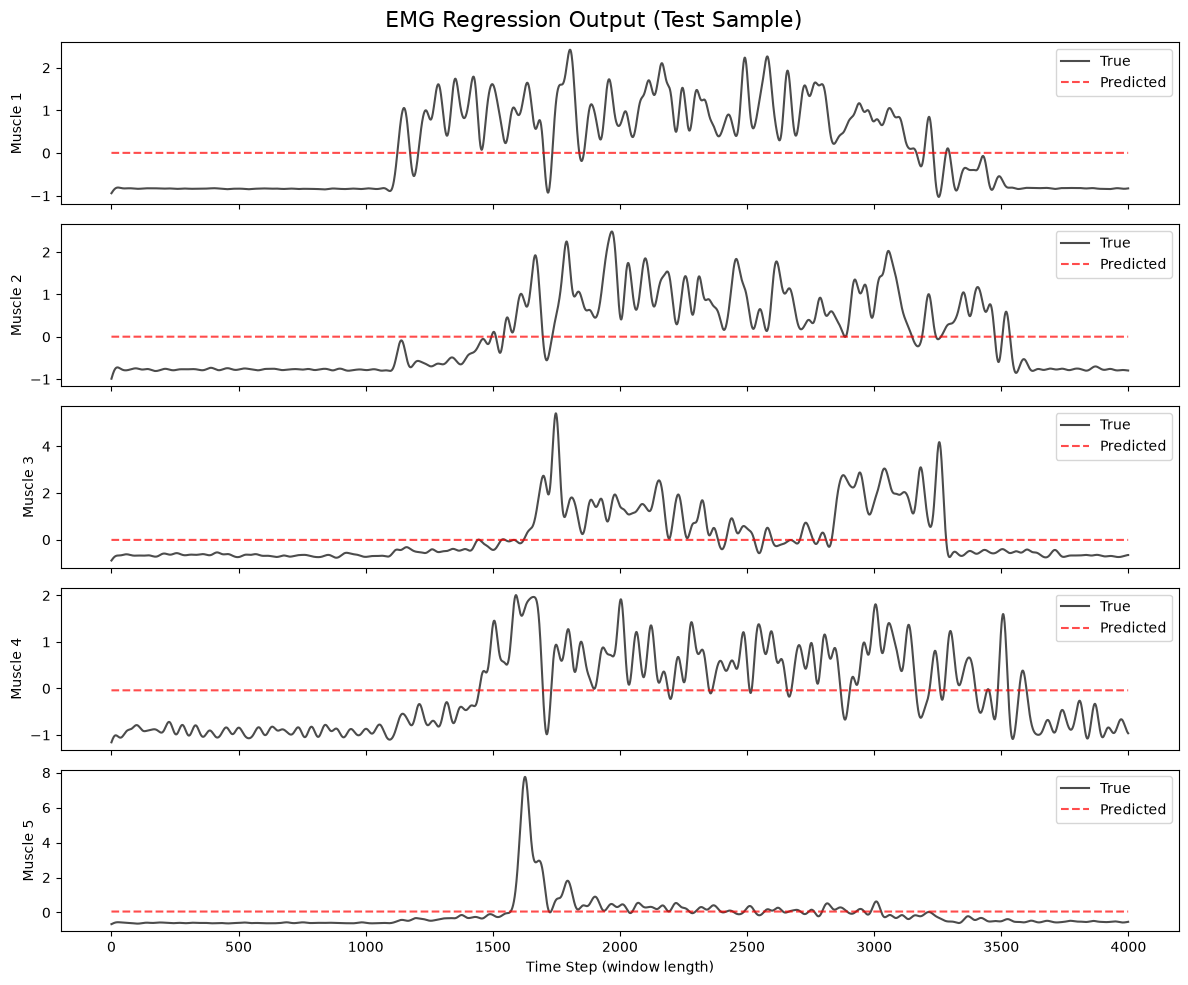

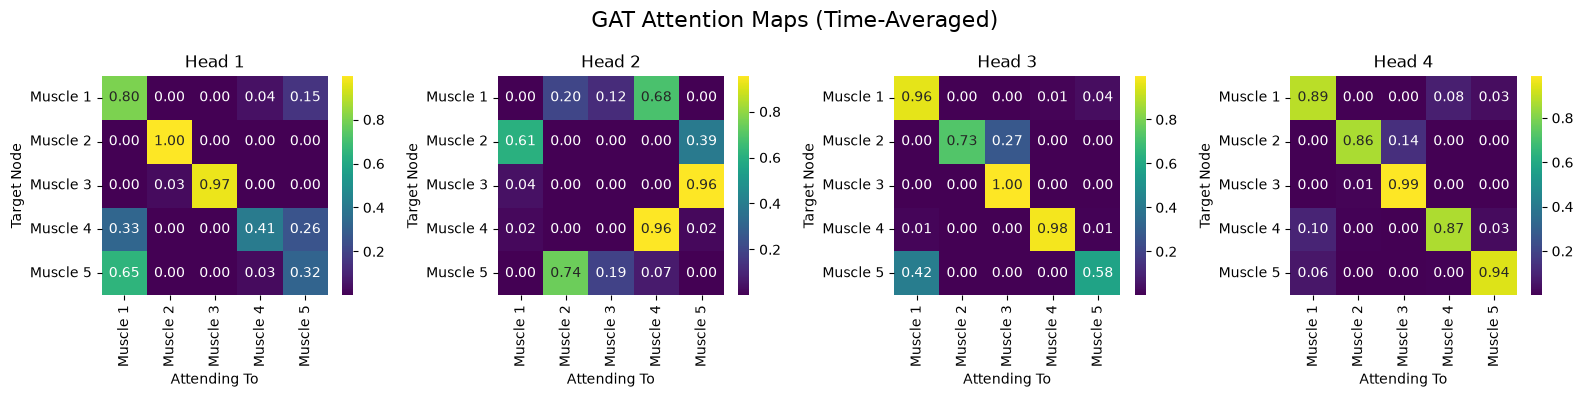

In [22]:
from asyncio import base_events
# ============================================================================
# Explainability and Evaluation Plots
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
with torch.no_grad():
    # Grab one batch from test_loader
    batch = next(iter(test_loader))
    eeg, kin, emg = batch
    batch_in, batch_target = prepare_batch(eeg, kin, emg)
    
    # Forward pass
    preds = model(**batch_in)
    
    # 1. Plot Predictions vs Targets for the first sample in batch
    sample_idx = 0
    y_true = batch_target[sample_idx].cpu().numpy()
    y_pred = preds[sample_idx].cpu().numpy()
    
    fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
    fig.suptitle("EMG Regression Output (Test Sample)", fontsize=16)
    muscle_names = ["Muscle 1", "Muscle 2", "Muscle 3", "Muscle 4", "Muscle 5"]
    for i in range(5):
        axes[i].plot(y_true[:, i], label='True', color='black', alpha=0.7)
        axes[i].plot(y_pred[:, i], label='Predicted', color='red', alpha=0.7, linestyle='--')
        axes[i].set_ylabel(muscle_names[i])
        axes[i].legend(loc="upper right")
    axes[-1].set_xlabel("Time Step (window length)")
    plt.tight_layout()
    plt.show()

    # 2. Extract and Plot GAT Attention Maps
    attn_weights = None
    if hasattr(model.gat, "last_attn_weights"):
        # KinematicGuidedMuscleGATEncoder
        attn_weights = model.gat.last_attn_weights
    elif hasattr(model.gat, "layers"):
        # MuscleGATEncoder (stacked layers)
        if hasattr(model.gat.layers[-1], "last_attn_weights"):
            attn_weights = model.gat.layers[-1].last_attn_weights
            
    if attn_weights is not None:
        # attn_weights is (B*T, H, N, N). We reshape to (B, T, H, N, N)
        B = preds.shape[0]
        T = preds.shape[1]
        H = attn_weights.shape[1]
        N = attn_weights.shape[2]
        attn_weights = attn_weights.view(B, T, H, N, N)
        
        # Average attention across all time steps for the first sample
        # Shape becomes (H, N, N)
        avg_attn = attn_weights[sample_idx].mean(dim=0).cpu().numpy()
        
        # Plot attention map for each head
        fig, axes = plt.subplots(1, H, figsize=(4 * H, 4))
        if H == 1:
            axes = [axes]
        fig.suptitle("GAT Attention Maps (Time-Averaged)", fontsize=16)
        
        for h in range(H):
            sns.heatmap(avg_attn[h], ax=axes[h], cmap="viridis", annot=True, fmt=".2f",
                        xticklabels=muscle_names, yticklabels=muscle_names)
            axes[h].set_title(f"Head {h+1}")
            axes[h].set_xlabel("Attending To")
            axes[h].set_ylabel("Target Node")
            
        plt.tight_layout()
        plt.show()
    else:
        print("Attention weights not found in GAT layer.")